# Diferencia de Medias/Medianas Global

En esta notebook se hace todo el analisis estadistico

In [1]:
a=1

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

import seaborn as sns

from scipy import stats

from sklearn.preprocessing import MinMaxScaler
from sklearn_extra.cluster import KMedoids

In [3]:
from scripts import style
style.mpl_apply()  

# Limpieza de Datos

In [4]:
materias = pd.read_excel('data/onedrive/Archivos2024/Materias estudiantes-profesores 2019-2025 P y O.xlsx')
materias_copy = materias.copy()

In [5]:
def clean_materias_df(materias: pd.DataFrame) -> pd.DataFrame:
    # IF CLAVEPROFESOR is nan and 'CLAVEALUMNO', 'CLAVEVARIANTEMATERIA', 'CALIFICACION' are the same, drop that row
    materias.sort_values(by=['CLAVEALUMNO', 'CLAVEVARIANTEMATERIA', 'CALIFICACION', 'CLAVEPROFESOR'], inplace=True)
    materias.drop_duplicates(subset=['CLAVEALUMNO', 'CLAVEVARIANTEMATERIA', 'CALIFICACION'], keep='first', inplace=True, ignore_index=True)

    # drop NUMORDEN column
    materias.drop(columns=['NUMORDEN'], inplace=True)

    # drop the rows where CLAVEPROFESOR is nan
    materias.dropna(subset=['CLAVEPROFESOR'], inplace=True)
    # make the CLAVEPROFESOR column integer
    materias['CLAVEPROFESOR'] = materias['CLAVEPROFESOR'].astype(int)
    return materias

materias = clean_materias_df(materias)

In [6]:
asesorias = pd.read_excel('data/onedrive/Archivos2024/Asesorias2024.xlsx')

# count how many times each id appears in 'id' column
asesoria_counts = asesorias['id'].value_counts()

# if id in materias['CLAVEALUMNO'] but not in asesoria_counts, assign 0 in materias_counts
asesoria_counts = asesoria_counts.reindex(materias['CLAVEALUMNO'].unique(), fill_value=0)


In [7]:
# if the id of asesorias_counts is in materias['CLAVEALUMNO'], map the count to a new column 'VISITAS' in materias
materias['VISITAS'] = materias['CLAVEALUMNO'].map(asesoria_counts)

# add the timmes each id appears as a new column 'asesoria_count' in asesorias
materias['VISITAS'] = materias['VISITAS'].fillna(0).astype(int)

In [8]:
def _silverman_bandwidth(x):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 2: return 0.1
    sd = np.std(x, ddof=1)
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    s = min(sd, iqr/1.34) if iqr > 0 else sd
    h = 0.9 * s * n**(-1/5)
    return max(h, 1e-3)

def _sample_kde_truncated(x_obs, size, low=0.0, high=7.5, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    x_obs = np.asarray(x_obs, dtype=float)
    h = _silverman_bandwidth(x_obs)
    out = np.empty(size, dtype=float); k = 0
    while k < size:
        batch = size - k
        idx = rng.integers(0, len(x_obs), size=batch)
        eps = rng.normal(0.0, h, size=batch)
        draw = x_obs[idx] + eps
        ok = (draw >= low) & (draw <= high)
        take = min(ok.sum(), batch)
        if take:
            out[k:k+take] = draw[ok][:take]
            k += take
    return out

def _sample_empirical(x_obs, size, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    x_obs = np.asarray(x_obs, dtype=float)
    return rng.choice(x_obs, size=size, replace=True)

def impute_nans_from_pre75_kde_df(
    df, value_col='CALIFICACION', out_col='IMPKDE',
    low=0.0, high=7.4, min_kde_n=20, seed=42,
    fallback='uniform',           # 'constant' | 'global' | 'parametric' | 'leave' | 'uniform'
    constant_value=6.5,
    prefer_empirical_if_small=True,
    global_source=None,
    debug=False
):
    rng = np.random.default_rng(seed)
    df = df.copy()

    num = pd.to_numeric(df[value_col], errors='coerce')
    df[out_col] = num
    nan_mask = num.isna()
    need = int(nan_mask.sum())
    if need == 0:
        return df

    obs_pre = num[~num.isna() & (num <= high)]

    def _borrow_pool():
        src = pd.to_numeric(global_source, errors='coerce') if global_source is not None else num
        return src[(~src.isna()) & (src <= high)]

    if len(obs_pre) >= min_kde_n:
        draws = _sample_kde_truncated(obs_pre.values, need, low=low, high=high, rng=rng)
    elif 0 < len(obs_pre) < min_kde_n:
        draws = np.clip(_sample_empirical(obs_pre.values, need, rng=rng), low, high)
    else:
        # No mass in [low, high]; choose fallback
        if fallback == 'global':
            pool = _borrow_pool()
            if len(pool) >= min_kde_n:
                draws = _sample_kde_truncated(pool.values, need, low=low, high=high, rng=rng)
            elif len(pool) > 0:
                draws = np.clip(_sample_empirical(pool.values, need, rng=rng), low, high)
            else:
                draws = np.full(need, min(constant_value, high))
        elif fallback == 'parametric':
            obs_all = num[~num.isna()]
            mu = float(obs_all.mean()) if len(obs_all) else 6.5
            sd = float(obs_all.std(ddof=1)) if len(obs_all) > 1 else 0.5
            sd = max(sd, 1e-3)
            k, draws = 0, np.empty(need)
            while k < need:
                batch = need - k
                cand = rng.normal(mu, sd, size=batch)
                ok = (cand >= low) & (cand <= high)
                take = min(ok.sum(), batch)
                if take:
                    draws[k:k+take] = cand[ok][:take]
                    k += take
        elif fallback == 'uniform':
            # Equally spaced interior points in [low, high]
            # order matches the order of NaNs in the DataFrame
            ks = np.arange(1, need + 1, dtype=float)
            draws = low + (ks / (need + 1.0)) * (high - low)
        elif fallback == 'leave':
            return df
        elif fallback == 'constant':
            draws = np.full(need, min(constant_value, high))
        else:
            raise ValueError("Unknown fallback")

    df.loc[nan_mask, out_col] = draws
    # hard bounds only on imputed entries
    vals = df.loc[nan_mask, out_col].to_numpy(dtype=float, copy=False)
    np.clip(vals, low, high, out=vals)
    df.loc[nan_mask, out_col] = vals
    return df



def get_salones_with_imputations():
    salones = {}

    # group by the 4 keys instead of nested loops
    grouped = materias.groupby(
        ['CLAVEPROFESOR', 'CLAVEVARIANTEMATERIA', 'anio', 'CLAVESESION'],
        sort=False
    )

    for (prof_id, materia, anio, sesion), sesion_materias in grouped:
        # IMPORTANT: work on a copy so assignments are safe
        sesion_materias = sesion_materias.copy()

        # 1) mean-imputation truncated at 7.5
        numeric_calificaciones = pd.to_numeric(
            sesion_materias['CALIFICACION'], errors='coerce'
        )
        mean_calificacion = numeric_calificaciones[
            numeric_calificaciones <= 7.5
        ].mean()

        sesion_materias.loc[:, 'IMPMEAN'] = numeric_calificaciones.fillna(
            mean_calificacion
        )

        mean = sesion_materias['IMPMEAN'].mean()
        std = sesion_materias['IMPMEAN'].std()

        # avoid division by zero just in case
        if std == 0 or pd.isna(std):
            sesion_materias.loc[:, 'IMPMEAN_Z'] = 0.0
        else:
            sesion_materias.loc[:, 'IMPMEAN_Z'] = (
                sesion_materias['IMPMEAN'] - mean
            ) / std

        # 2) KDE-based imputation
        sesion_materias = impute_nans_from_pre75_kde_df(
            sesion_materias,
            value_col='CALIFICACION',
            out_col='IMPKDE',
            constant_value=6.5,
            fallback='uniform',
        )

        mean_kde = sesion_materias['IMPKDE'].mean()
        std_kde = sesion_materias['IMPKDE'].std()

        if std_kde == 0 or pd.isna(std_kde):
            sesion_materias.loc[:, 'IMPKDE_Z'] = 0.0
        else:
            sesion_materias.loc[:, 'IMPKDE_Z'] = (
                sesion_materias['IMPKDE'] - mean_kde
            ) / std_kde

        # store the processed DataFrame
        salones[(prof_id, materia, anio, sesion)] = sesion_materias

    return salones


salones = get_salones_with_imputations()

In [9]:
salon = salones[(23453, 'MAT1012', 2020, 'PRIMAVERA')]
salon['CALIFICACION'] = pd.to_numeric(salon['CALIFICACION'], errors='coerce')

ultramerge = pd.concat(salones.values(), ignore_index=True)
ultramerge['CALIFICACION'] = pd.to_numeric(ultramerge['CALIFICACION'], errors='coerce')

# get the mean of each CLAVEALUMNO in ultramerge
ultramerge_means = ultramerge.groupby('CLAVEALUMNO')['IMPKDE_Z'].mean().reset_index()
ultramerge_means.rename(columns={'IMPKDE_Z': 'MEAN_IMPKDE_Z'}, inplace=True)
ultramerge_means = ultramerge_means.merge(materias[['CLAVEALUMNO', 'VISITAS']].drop_duplicates(), on='CLAVEALUMNO', how='left')
ultramerge['CALIFICACION'] = pd.to_numeric(ultramerge['CALIFICACION'], errors='coerce')
# ultramerge_means.sort_values(by='MEAN_IMPKDE_Z', ascending=False).head(10)

# Visualizacion de las Tablas

In [10]:
print(asesorias.shape)
asesorias.head()

(13500, 8)


,fecha,id,carrera,semestre,profesor,materia,tema,periodo
0,2024-02-08 10:06:02,0,Ingeniería Mecánica,2,Daniela Rodríguez Tzompantzi,Cálculo I,Derivadas,P
1,2023-08-14 10:02:28,0,Física,3,Azucena Tochimani Tiro,Cálculo II,Sucesiones y series,O
2,2022-01-03 09:15:51,0,Psicología Clínica,2,DIEGO RODRIGUEZ CENTENO,Estadística Para Ciencias Sociales,Probabilidad,P
3,2021-03-19 20:36:13,0,Ingeniería Industrial,2,Miguel Pérez Gaspar,Cálculo I,Derivadas,P
4,2020-09-21 16:01:13,0,Ingeniería en Sistemas Computacionales,1,Anel Vázquez Martínez,Matemáticas Universitarias,Conceptos fundamentales algebra,O


In [11]:
print(materias.shape)
materias.head()

(26140, 9)


,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,VISITAS
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453,0
1,92988,LPA,2019,OTOÑO,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9.6,21815,3
2,94286,LEF,2022,OTOÑO,MAT2092,ESTADÍSTICA PARA CIENCIAS DE LA SALUD,7.7,22109,3
3,111083,LFP,2024,PRIMAVERA,MAT1022,CÁLCULO I,10,24085,0
9,140079,LNA,2023,OTOÑO,MAT1022,CÁLCULO I,9.2,23152,49


In [12]:
print(ultramerge.shape)
ultramerge.head()

(26140, 13)


,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,VISITAS,IMPMEAN,IMPMEAN_Z,IMPKDE,IMPKDE_Z
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,NaN,23453,0,5.355,-0.639014,0.5,-2.346103
1,162163,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,0.5,23453,0,0.500,-2.745662,0.5,-2.346103
2,164382,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,5.3,23453,0,5.300,-0.662880,5.3,-0.513402
3,164516,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,23453,0,7.500,0.291729,7.5,0.326586
4,164551,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.8,23453,0,7.800,0.421903,7.8,0.441130


In [27]:
# print unique values of materias['CLAVEVARIANTEMATERIA']
print(materias['CLAVEVARIANTEMATERIA'].unique())

print(materias['DESCRIBEMATERIA'].unique())


['MAT1012' 'MAT1052' 'MAT2092' 'MAT1022' 'MAT1032' 'MAT2012' 'MAT2022']
['MATEMÁTICAS UNIVERSITARIAS' 'ESTADÍSTICA PARA CIENCIAS SOCIALES'
 'ESTADÍSTICA PARA CIENCIAS DE LA SALUD' 'CÁLCULO I' 'ÁLGEBRA LINEAL'
 'CÁLCULO II' 'ESTADÍSTICA PARA NEGOCIOS I']


In [13]:
MATERIA = 'MAT1012'

In [14]:
ultramerge = ultramerge[ultramerge['CLAVEVARIANTEMATERIA'] == MATERIA]
print(ultramerge.shape)
ultramerge.head()

(8892, 13)


,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,VISITAS,IMPMEAN,IMPMEAN_Z,IMPKDE,IMPKDE_Z
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,NaN,23453,0,5.355,-0.639014,0.5,-2.346103
1,162163,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,0.5,23453,0,0.500,-2.745662,0.5,-2.346103
2,164382,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,5.3,23453,0,5.300,-0.662880,5.3,-0.513402
3,164516,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,23453,0,7.500,0.291729,7.5,0.326586
4,164551,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.8,23453,0,7.800,0.421903,7.8,0.441130


In [15]:
import os
PATH = f'visualizations/figuras/{MATERIA}/'
os.makedirs(PATH, exist_ok=True)

# Analisis de Calificaciones

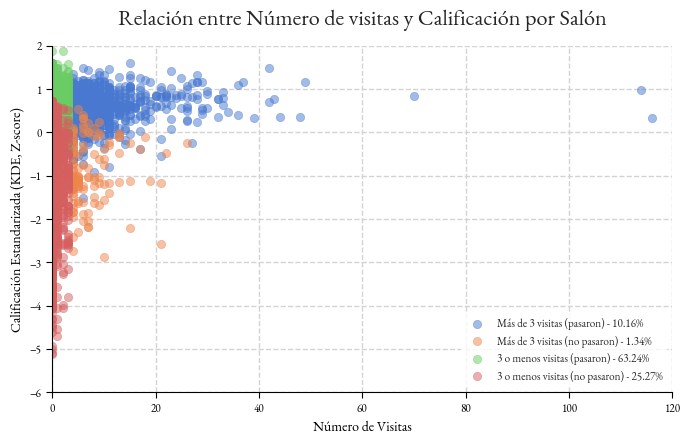

In [ ]:
# they went more than 3, and they passed
group1 = ultramerge[(ultramerge['VISITAS'] > 3) & ((ultramerge['CALIFICACION'].notna()) & (ultramerge['CALIFICACION'] >= 7.5))]

# they went more than 3, and they did not pass
group2 = ultramerge[(ultramerge['VISITAS'] > 3) & ((ultramerge['CALIFICACION'].isna()) | (ultramerge['CALIFICACION'] < 7.5))]


# they went less than 3, and they passed
group3 = ultramerge[(ultramerge['VISITAS'] <= 3) & ((ultramerge['CALIFICACION'].notna()) & (ultramerge['CALIFICACION'] >= 7.5))]

# they went less than 3, and they did not pass
group4 = ultramerge[(ultramerge['VISITAS'] <= 3) & ((ultramerge['CALIFICACION'].isna()) | (ultramerge['CALIFICACION'] < 7.5))]


# get the percentage of each group
total_students = len(ultramerge)
perc_group1 = (len(group1) / total_students) * 100
perc_group2 = (len(group2) / total_students) * 100
perc_group3 = (len(group3) / total_students) * 100
perc_group4 = (len(group4) / total_students) * 100


# SCATTERPLOT, x=VISITAS, y=IMPKDE_Z
# remove the border of each point with sns.scatterplot
sns.scatterplot(data=group1, x='VISITAS', y='IMPKDE_Z', alpha=0.5, label=f'Más de 3 visitas (pasaron) - {perc_group1:.2f}%', edgecolor=None)
sns.scatterplot(data=group2, x='VISITAS', y='IMPKDE_Z', alpha=0.5, label=f'Más de 3 visitas (no pasaron) - {perc_group2:.2f}%', edgecolor=None)
sns.scatterplot(data=group3, x='VISITAS', y='IMPKDE_Z', alpha=0.5, label=f'3 o menos visitas (pasaron) - {perc_group3:.2f}%', edgecolor=None)
sns.scatterplot(data=group4, x='VISITAS', y='IMPKDE_Z', alpha=0.5, label=f'3 o menos visitas (no pasaron) - {perc_group4:.2f}%', edgecolor=None)
plt.title('Relación entre Número de visitas y Calificación por Salón')
plt.xlabel('Número de Visitas')
plt.ylabel('Calificación Estandarizada (KDE, Z-score)')
plt.legend(loc='lower right')

plt.savefig(PATH + '07_00.pdf', bbox_inches='tight')

plt.show()


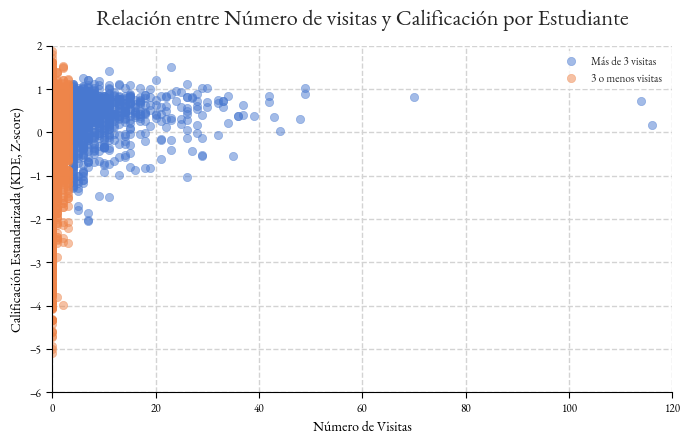

In [17]:
# SCATTERPLOT, x=VISITAS, y=IMPKDE_Z
# remove the border of each point with sns.scatterplot
sns.scatterplot(data=ultramerge_means[ultramerge_means['VISITAS'] > 3], x='VISITAS', y='MEAN_IMPKDE_Z', alpha=0.5, label='Más de 3 visitas', edgecolor=None)
sns.scatterplot(data=ultramerge_means[ultramerge_means['VISITAS'] <= 3], x='VISITAS', y='MEAN_IMPKDE_Z', alpha=0.5, label='3 o menos visitas', edgecolor=None)


plt.title('Relación entre Número de visitas y Calificación por Estudiante')
plt.xlabel('Número de Visitas')
plt.ylabel('Calificación Estandarizada (KDE, Z-score)')
plt.legend()

plt.savefig(PATH + '08_00.pdf', bbox_inches='tight')

plt.show()

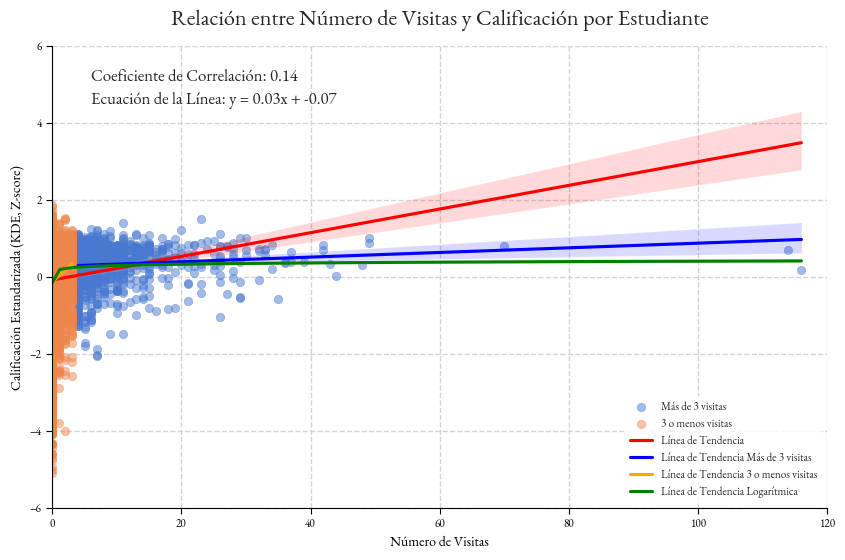

In [18]:
# SCATTERPLOT, x=VISITAS, y=IMPKDE_Z
plt.figure(figsize=(10, 6)) 
# remove the border of each point with sns.scatterplot
sns.scatterplot(data=ultramerge_means[ultramerge_means['VISITAS'] > 3], x='VISITAS', y='MEAN_IMPKDE_Z', alpha=0.5, label='Más de 3 visitas', edgecolor=None)
sns.scatterplot(data=ultramerge_means[ultramerge_means['VISITAS'] <= 3], x='VISITAS', y='MEAN_IMPKDE_Z', alpha=0.5, label='3 o menos visitas', edgecolor=None)

# add a regression line
sns.regplot(data=ultramerge_means, x='VISITAS', y='MEAN_IMPKDE_Z', scatter=False, color='red', line_kws={'label':"Línea de Tendencia"}, label='Línea de Tendencia')
sns.regplot(data=ultramerge_means[ultramerge_means['VISITAS'] > 3], x='VISITAS', y='MEAN_IMPKDE_Z', scatter=False, color='blue', line_kws={'label':"Línea de Tendencia Más de 3 visitas"}, label='Línea de Tendencia Más de 3 visitas')
sns.regplot(data=ultramerge_means[ultramerge_means['VISITAS'] <= 3], x='VISITAS', y='MEAN_IMPKDE_Z', scatter=False, color='orange', line_kws={'label':"Línea de Tendencia 3 o menos visitas"}, label='Línea de Tendencia 3 o menos visitas')

# get the slope and intercept of the regression line
import statsmodels.api as sm
X = sm.add_constant(ultramerge_means['VISITAS'])
model = sm.OLS(ultramerge_means['MEAN_IMPKDE_Z'], X).fit()
slope = model.params['VISITAS']
intercept = model.params['const']
plt.text(0.05, 0.90, f'Ecuación de la Línea: y = {slope:.2f}x + {intercept:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')


# get the correlation coefficient
corr = ultramerge_means['VISITAS'].corr(ultramerge_means['MEAN_IMPKDE_Z'])
plt.text(0.05, 0.95, f'Coeficiente de Correlación: {corr:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

# it is like a logarithmic relationship
# change the 0 to 0.1 to avoid log(0)
ultramerge_logs = ultramerge_means.copy()
ultramerge_logs['VISITAS'] = ultramerge_logs['VISITAS'].replace(0, 0.001)
sns.regplot(data=ultramerge_logs, x='VISITAS', y='MEAN_IMPKDE_Z', scatter=False, color='green', line_kws={'label':"Línea de Tendencia Logarítmica"}, label='Línea de Tendencia Logarítmica', logx=True)

plt.title('Relación entre Número de Visitas y Calificación por Estudiante')
plt.xlabel('Número de Visitas')
plt.ylabel('Calificación Estandarizada (KDE, Z-score)')
plt.legend()
plt.show()

# Diferencia de medias


        T-estadístico: 22.61, P-valor: 0.0000 
        La diferencia es estadísticamente significativa. 
        Media de más de 3 visitas: 0.34 
        Media de 3 o menos visitas: -0.08 
        Diferencia de medias: 0.41 
        Tamaño de muestra más de 3 visitas: 1036 
        Tamaño de muestra 3 o menos visitas: 9377
        
Shapiro-Wilk Para Grupo 1 - Estadistico: 0.9141959470023671, P-valor: 9.529511359611e-24
El Grupo 1 no se distribuye normalmente


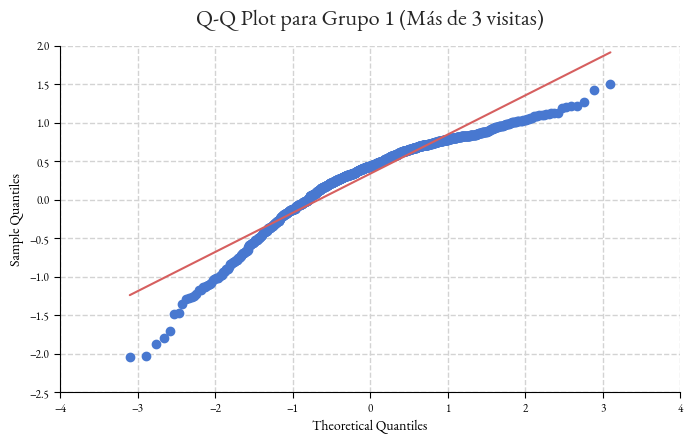

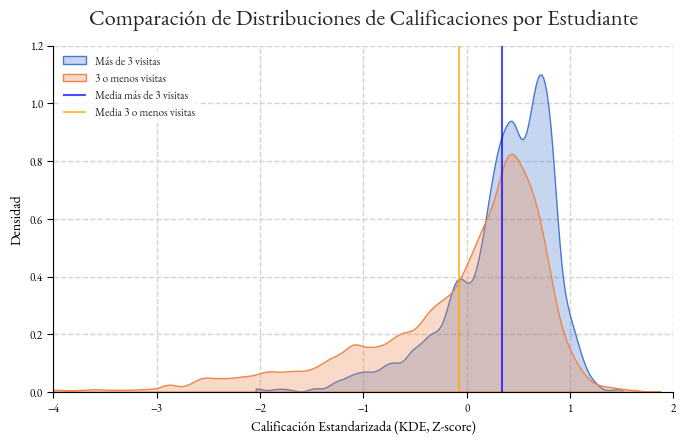

In [31]:
# compare the zscore of each group and test the difference of means
def pruebas_parametricas(group1, group2, estudiante_o_calificacion='Calificación'):
    t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)
    if p_value < 0.05:
        text = f"""
        T-estadístico: {t_stat:.2f}, P-valor: {p_value:.4f} 
        La diferencia es estadísticamente significativa. 
        Media de más de 3 visitas: {group1.mean():.2f} 
        Media de 3 o menos visitas: {group2.mean():.2f} 
        Diferencia de medias: {group1.mean() - group2.mean():.2f} 
        Tamaño de muestra más de 3 visitas: {len(group1)} 
        Tamaño de muestra 3 o menos visitas: {len(group2)}
        """
        print(text.format(
            t_stat=t_stat,
            p_value=p_value,
            group1=group1,
            group2=group2,
            len=len
        ))

    # verify if group1 is distributed normally
    stat, p = stats.shapiro(group1)
    print(f'Shapiro-Wilk Para Grupo 1 - Estadistico: {stat}, P-valor: {p}')
    if p > 0.05:
        print(f"El Grupo 1 se distribuye normalmente")
    else:
        print("El Grupo 1 no se distribuye normalmente")

        # qqplot 
        sm.qqplot(group1, line ='s')
        plt.title('Q-Q Plot para Grupo 1 (Más de 3 visitas)')
        plt.savefig(f'{PATH}08_Parametricas_{estudiante_o_calificacion}_NoNormalidad.pdf', bbox_inches='tight')
        plt.show()


    sns.kdeplot(group1, cut=0, bw_adjust=0.5, fill=True, alpha=0.3, label='Más de 3 visitas')
    sns.kdeplot(group2, cut=0, bw_adjust=0.5, fill=True, alpha=0.3, label='3 o menos visitas')
    plt.title(f'Comparación de Distribuciones de Calificaciones por {estudiante_o_calificacion}')
    plt.xlabel('Calificación Estandarizada (KDE, Z-score)')
    plt.ylabel('Densidad')
    plt.vlines(x=group1.mean(), ymin=0, ymax=1.2, colors='blue', linestyles='-', label='Media más de 3 visitas', alpha=0.7)
    plt.vlines(x=group2.mean(), ymin=0, ymax=1.2, colors='orange', linestyles='-', label='Media 3 o menos visitas', alpha=0.7)
    plt.legend(loc='upper left')
    plt.xlim(-4, 2)
    plt.savefig(f'{PATH}08_Parametricas_{estudiante_o_calificacion}.pdf', bbox_inches='tight')
    plt.show()

group1 = ultramerge_means[ultramerge_means['VISITAS'] > 3]['MEAN_IMPKDE_Z']
group2 = ultramerge_means[ultramerge_means['VISITAS'] <= 3]['MEAN_IMPKDE_Z']
pruebas_parametricas(group1, group2, estudiante_o_calificacion='Estudiante')


        T-estadístico: 19.50, P-valor: 0.0000 
        La diferencia es estadísticamente significativa. 
        Media de más de 3 visitas: 0.40 
        Media de 3 o menos visitas: -0.05 
        Diferencia de medias: 0.45 
        Tamaño de muestra más de 3 visitas: 1022 
        Tamaño de muestra 3 o menos visitas: 7870
        
Shapiro-Wilk Para Grupo 1 - Estadistico: 0.8325623328543077, P-valor: 2.0929415162937984e-31
El Grupo 1 no se distribuye normalmente


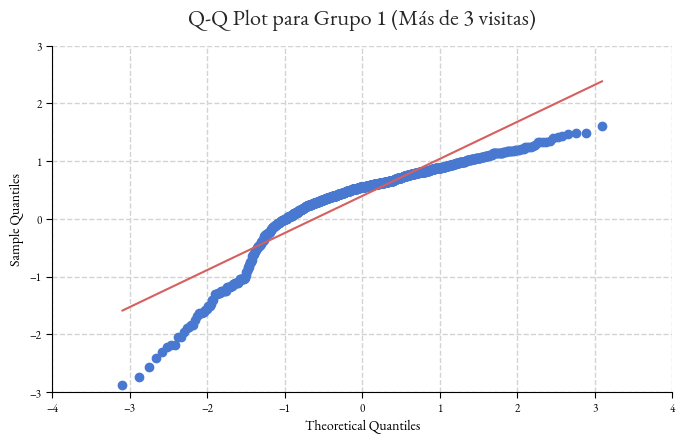

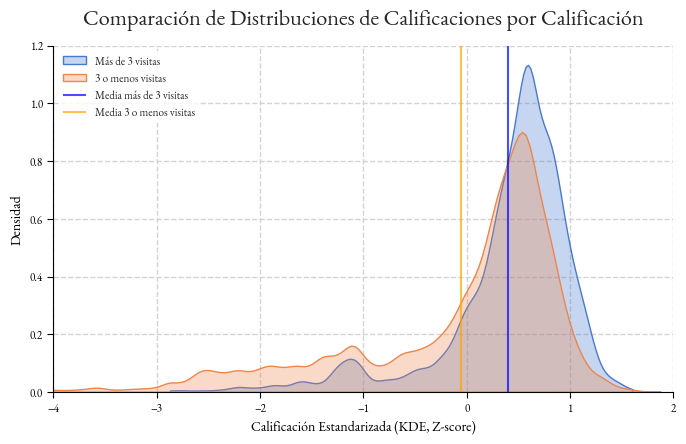

In [32]:
group1 = ultramerge[ultramerge['VISITAS'] > 3]['IMPKDE_Z']
group2 = ultramerge[ultramerge['VISITAS'] <= 3]['IMPKDE_Z']
pruebas_parametricas(group1, group2, estudiante_o_calificacion='Calificación')

# Metodos no parametricos

In [40]:
def pruebas_no_parametricas_two_sample(group1, group2, estudiante_o_calificacion='Calificación'):
    n1, n2 = len(group1), len(group2)

    # 1) Mann–Whitney U (Wilcoxon rank-sum)
    U, p_mw = stats.mannwhitneyu(group1, group2, alternative='two-sided', method='auto')
    U_star = max(U, n1*n2 - U)                       # for CL
    CL = U_star / (n1*n2)                            # common-language effect size
    r_rb = 2*CL - 1                                  # rank-biserial correlation

    # 2) Brunner–Munzel
    bm_stat, p_bm = stats.brunnermunzel(group1, group2, alternative='two-sided')

    # 3) Robust median shift with bootstrap CI
    def bootstrap_diff_median(x, y, B=10000, seed=0):
        rng = np.random.default_rng(seed)
        diffs = np.empty(B, float)
        n1, n2 = len(x), len(y)
        for b in range(B):
            xb = rng.choice(x, n1, replace=True)
            yb = rng.choice(y, n2, replace=True)
            diffs[b] = np.median(xb) - np.median(yb)
        ci = np.quantile(diffs, [0.025, 0.975])
        return np.median(x) - np.median(y), ci, diffs

    dmed, ci_med, _ = bootstrap_diff_median(group1, group2, B=8000, seed=42)

    # 4) Permutation test on the median difference
    def stat_median(x, y):
        return np.median(x) - np.median(y)

    perm = stats.permutation_test((group1, group2), stat_median,
                                n_resamples=5000, alternative='two-sided',
                                random_state=42)
    p_perm_med = perm.pvalue

    # 5) Cliff's delta (approx if very large)
    def cliffs_delta(x, y, max_pairs=5_000_000, seed=0):
        x = np.asarray(x); y = np.asarray(y)
        n1, n2 = len(x), len(y)
        rng = np.random.default_rng(seed)
        if n1*n2 > max_pairs:
            m = int(np.sqrt(max_pairs))
            X = x[rng.integers(0, n1, m)]
            Y = y[rng.integers(0, n2, m)]
        else:
            X, Y = x, y
        cmp = X[:, None] - Y[None, :]
        gt = np.sum(cmp > 0)
        lt = np.sum(cmp < 0)
        return (gt - lt) / (X.size * Y.size)

    delta = cliffs_delta(group1, group2)

    def bootstrap_ci_two_sample(x, y, stat_fn, B=5000, seed=0, alpha=0.05):
        """
        Generic bootstrap CI for a two-sample statistic.

        x, y      : 1D arrays
        stat_fn   : function taking (x, y) and returning a scalar
        B         : number of bootstrap resamples
        alpha     : 1 - CI level (0.05 -> 95% CI)
        """
        rng = np.random.default_rng(seed)
        x = np.asarray(x)
        y = np.asarray(y)
        n1, n2 = len(x), len(y)

        boot_stats = np.empty(B, float)
        for b in range(B):
            xb = rng.choice(x, n1, replace=True)
            yb = rng.choice(y, n2, replace=True)
            boot_stats[b] = stat_fn(xb, yb)

        lower, upper = np.quantile(boot_stats, [alpha/2, 1 - alpha/2])
        return (lower, upper), boot_stats

    U, p_mw = stats.mannwhitneyu(group1, group2, alternative='two-sided', method='auto')
    U_star = max(U, n1*n2 - U)                       # for CL
    CL = U_star / (n1*n2)                            # common-language effect size
    r_rb = 2*CL - 1                                  # rank-biserial correlation


    def stat_CL(x, y):
        n1, n2 = len(x), len(y)
        U, _ = stats.mannwhitneyu(x, y, alternative='two-sided', method='auto')
        U_star = max(U, n1*n2 - U)
        CL = U_star / (n1*n2)
        return CL

    # Bootstrap CI for CL
    ci_CL, _ = bootstrap_ci_two_sample(group1, group2, stat_CL, B=4000, seed=123)

    # From CL we derive r_rb, so we can bootstrap it directly as well:
    def stat_r_rb(x, y):
        cl = stat_CL(x, y)
        return 2*cl - 1

    ci_r_rb, _ = bootstrap_ci_two_sample(group1, group2, stat_r_rb, B=4000, seed=123)

    def stat_delta(x, y):
        return cliffs_delta(x, y)

    ci_delta, _ = bootstrap_ci_two_sample(group1, group2, stat_delta, B=400, seed=456)

    dmed, ci_med, _ = bootstrap_diff_median(group1, group2, B=800, seed=42)

    def stat_median_diff(x, y):
        return np.median(x) - np.median(y)

    ci_med2, diffs = bootstrap_ci_two_sample(group1, group2, stat_median_diff, B=800, seed=42)
    dmed2 = stat_median_diff(group1, group2)

    m1, m2 = np.median(group1), np.median(group2)
    text = (
        f"Mediana (más de 3 visitas) = {m1:.3f}\n"
        f"Mediana (3 o menos visitas) = {m2:.3f}\n"
        f"Mann–Whitney U p={p_mw:.4g}, "
        f"CL={CL:.3f} CI95% [{ci_CL[0]:.3f}, {ci_CL[1]:.3f}], "
        f"r_rb={r_rb:.3f} CI95% [{ci_r_rb[0]:.3f}, {ci_r_rb[1]:.3f}]\n"
        f"Brunner–Munzel p={p_bm:.4g}\n"
        f"Δ mediana = {dmed:.3f}  CI95% [{ci_med[0]:.3f}, {ci_med[1]:.3f}]  "
        f"Permutación p_mediana={p_perm_med:.4g}\n"
        f"Cliff’s δ={delta:.3f} CI95% [{ci_delta[0]:.3f}, {ci_delta[1]:.3f}]"
    )
    print(text)

    # get percentages
    total = len(group1) + len(group2)
    perc1 = (len(group1) / total) * 100
    perc2 = (len(group2) / total) * 100

    # ---- Plot with medians and robust stats

    sns.kdeplot(group1, cut=0, bw_adjust=0.5, fill=True, alpha=0.3, label=f'Más de 3 visitas ({perc1:.2f}%)')
    sns.kdeplot(group2, cut=0, bw_adjust=0.5, fill=True, alpha=0.3, label=f'3 o menos visitas ({perc2:.2f}%)')
    
    plt.vlines(x=group1.mean(), ymin=0, ymax=1.2, colors='blue', linestyles='-', label=f'Mediana más de 3 visitas {m1:.2f}', alpha=0.7)
    plt.vlines(x=group2.mean(), ymin=0, ymax=1.2, colors='orange', linestyles='-', label=f'Mediana 3 o menos visitas {m2:.2f}', alpha=0.7)
    plt.title(f'Comparación robusta de Distribuciones por {estudiante_o_calificacion}')
    plt.xlabel('Calificación Estandarizada (KDE, Z-score)')
    plt.ylabel('Densidad')
    plt.legend(loc='upper left')
    plt.xlim(-4, 2)
    plt.savefig(f'{PATH}08_NoParametricos_{estudiante_o_calificacion}.pdf', bbox_inches='tight')
    plt.show()

Mediana (más de 3 visitas) = 0.438
Mediana (3 o menos visitas) = 0.202
Mann–Whitney U p=2.012e-51, CL=0.643 CI95% [0.626, 0.659], r_rb=0.285 CI95% [0.253, 0.317]
Brunner–Munzel p=1.784e-59
Δ mediana = 0.235  CI95% [0.200, 0.267]  Permutación p_mediana=0.0003999
Cliff’s δ=0.282 CI95% [0.235, 0.329]


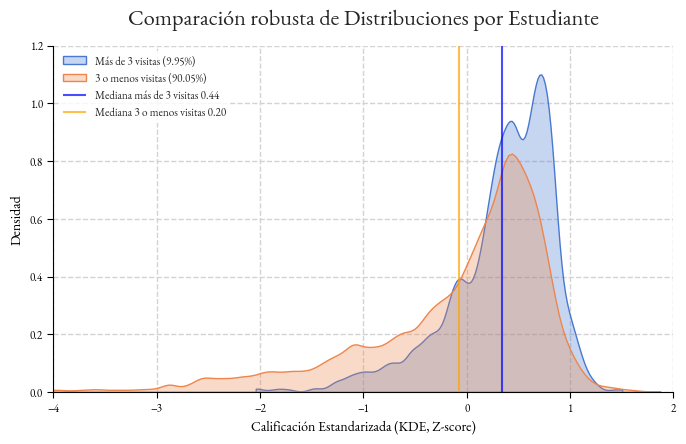

In [41]:
# Split groups
group1 = ultramerge_means[ultramerge_means['VISITAS'] > 3]['MEAN_IMPKDE_Z'].dropna().to_numpy()
group2 = ultramerge_means[ultramerge_means['VISITAS'] <= 3]['MEAN_IMPKDE_Z'].dropna().to_numpy()
pruebas_no_parametricas_two_sample(group1, group2, estudiante_o_calificacion='Estudiante')

Mediana (más de 3 visitas) = 0.553
Mediana (3 o menos visitas) = 0.322
Mann–Whitney U p=1.2e-51, CL=0.645 CI95% [0.628, 0.663], r_rb=0.290 CI95% [0.256, 0.326]
Brunner–Munzel p=8.558e-57
Δ mediana = 0.231  CI95% [0.200, 0.256]  Permutación p_mediana=0.0003999
Cliff’s δ=0.250 CI95% [0.238, 0.336]


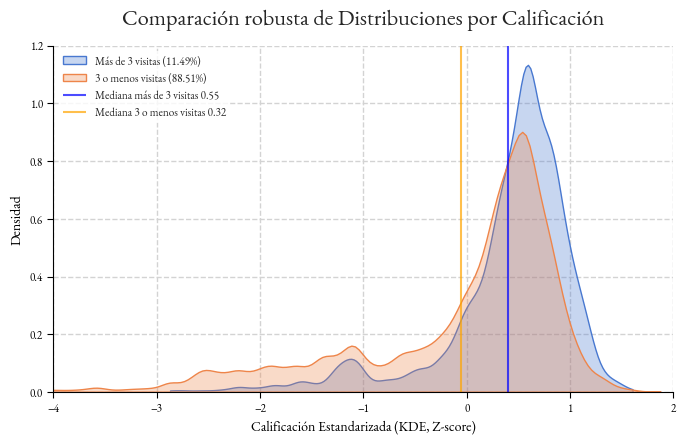

In [42]:
# Split groups
group1 = ultramerge[ultramerge['VISITAS'] > 3]['IMPKDE_Z'].dropna().to_numpy()
group2 = ultramerge[ultramerge['VISITAS'] <= 3]['IMPKDE_Z'].dropna().to_numpy()
pruebas_no_parametricas_two_sample(group1, group2, estudiante_o_calificacion='Calificación')

# Z promedio por estudiante

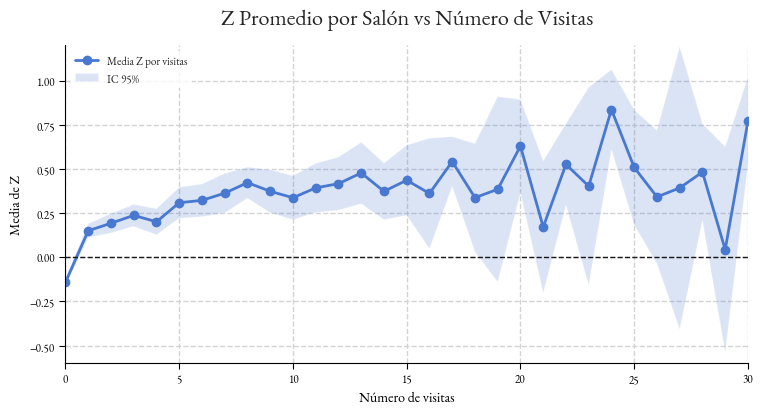

In [25]:
# agrupa por VISITAS y calcula media y error estándar
df = ultramerge_means[['VISITAS','MEAN_IMPKDE_Z']].dropna().copy()
agg = df.groupby('VISITAS')['MEAN_IMPKDE_Z'].agg(['mean','count','std'])
agg['se'] = agg['std'] / np.sqrt(agg['count'])
# intervalo de confianza 95% aproximado
agg['lo'] = agg['mean'] - 1.96*agg['se']
agg['hi'] = agg['mean'] + 1.96*agg['se']

plt.plot(agg.index, agg['mean'], marker='o', linewidth=2, label='Media Z por visitas')
plt.fill_between(agg.index, agg['lo'], agg['hi'], alpha=0.2, label='IC 95%')
plt.axhline(0, color='k', linewidth=1, linestyle='--')
plt.xlabel('Número de visitas')
plt.ylabel('Media de Z')
plt.title('Z Promedio por Salón vs Número de Visitas')
plt.legend()
plt.tight_layout()
plt.xlim(0, 30)

plt.savefig(f'{PATH}09_01.pdf', bbox_inches='tight')
plt.show()
